# Proyecto Fin de Curso: Predicción de la Demanda Energética en España (2015-2018)


**Estudiante:** Marta Requejo Merino 

**Especialidad:** Grado en IA y Big Data 

---

## 1. Definición del Problema de Machine Learning
El objetivo de este proyecto es desarrollar un sistema capaz de **predecir la demanda de energía eléctrica** en España. 

* **Tipo de Problema:** Estamos antes un problema de **Regresión**. Buscamos predecir una variable continua y numérica expresada en Megavatios (MW).
* **Utilidad Real:** En el sector eléctrico, la oferta y la demanda deben estar perfectamente balanceadas en tiempo real para evitar apagones, ya que la electricidad no se puede almacenar eficientemente a gran escala. Una predicción precisa permite a los operadores de red planificar el mix de generación óptimo, minimizando el uso de centrales térmicas de respaldo costosas y contaminantes, y maximizando la integración de energías renovables.

## 2. Identificación y Justificación de Variables

El dataset combina registros históricos de consumo energético nacional con variables climatológicas de las 5 ciudades más pobladas de España (Madrid, Barcelona, Valencia, Sevilla y Bilbao), cubriendo el periodo de 2015 a 2018.

### Variable objetivo:

- `total_load_actual`: Demanda eléctrica real en Megavatios (MW). Es la variable que nuestro modelo debe predecir.

### Variables independientes (Features):

- Temporales: `hour, month, day_of_week`. Justificadas por la naturaleza cíclica del consumo eléctrico humano (hábitos diarios, estacionalidad mensual y diferencias entre fines de semana y días laborables).

- Meteorológicas: `temp_madrid, temp_barcelona, temp_seville, temp_valencia, temp_bilbao`. Justificadas por la dependencia térmica del consumo; la temperatura es el predictor externo más potente para entender el uso de sistemas de calefacción y refrigeración.

Conforme vayamos haciendo el estudio de datos se contemplará si hay alguna variable que sea necesaria para el entrenamiento del modelo.

## 3. Arquitectura de Ingesta y Almacenamiento

Se ha diseñado e implementado una **arquitectura de procesamiento en la nube** basada en los servicios de Amazon Web Services (AWS), estructurada en diferentes capas para garantizar escalabilidad, eficiencia en costes y rendimiento analítico. La orquestación del flujo de datos y la integración de los servicios se ha programado en Python, utilizando **Boto3 (AWS SDK)** como librería principal:

1. **Capa Raw (Amazon S3):** Los archivos CSV originales se ingieren línea a línea mediante scripts locales de Python (`boto3`) y se almacenan en un bucket particionados cronológicamente (`year=YYYY/month=MM/day=DD/`). Es una capa inmutable.
2. **Crawlers:** Un Glue Crawler escanea automáticamente la capa Raw para inferir esquemas y crear tablas lógicas virtuales, evitando la configuración manual de tipos de datos.
3. **Amazon Athena:**Mediante consultas distribuidas en SQL, se realiza el cruce de datasets (JOIN), la deduplicación de energía, la limpieza de caracteres y el pivoteo matricial de las variables climáticas. Se ha optado por la potencia de este motor SQL frente a AWS Glue ETL bajo un enfoque moderno ELT (Extract, Load, Transform) porque transforma los datos al vuelo, reduciendo drásticamente los tiempos de ejecución y los costes al prescindir de clústeres dedicados.
4. **Capa Processed (Amazon S3):** Athena exporta la tabla unificada final en formato **Apache Parquet**, un almacenamiento columnar comprimido ideal para la carga masiva y veloz hacia el entorno de Jupyter Notebook en la fase de Data Science.

> **Nota:** El código fuente correspondiente a la ingesta de datos y a la orquestación de la infraestructura en la nube no se incluye en este cuaderno. Siguiendo las mejores prácticas de desarrollo, dichos procesos se han modularizado en scripts de Python independientes (archivos `.py`) que se encuentran adjuntos en el directorio `scripts/` del proyecto.


### 3.1 Justificación técnica

- **AWS** : Es el estándar de la industria en la nube. AWS ofrece escalabilidad infinita, si mañana mis datos pasan de ser 3 años a 30 años Amazon me lo permite siempre y cuando el haya suficiente presupuesto, además ofrece planes gratuitos para alumnos que permiten que proyectos como este puedan hacerse de forma gratuita.
- **S3**: Actúa como un Data Lake inmutable. Al ser el punto de entrada, garantiza que los datos raw nunca se pierdan, permitiéndo re-procesarlos tantas veces como se necesite sin dañar la fuente original.
- **Glue y Athena**: Al utilizar S3 como Data Lake inmutable, el paso lógico para el procesamiento es integrar AWS Glue y Athena, ya que ofrecen una solución serverless de alto rendimiento para transformar nuestros datasets masivos. Glue actúa como un catálogo inteligente que automatiza la detección de esquemas mediante crawlers, facilitando la gestión de cientos de columnas sin intervención manual, mientras que Athena nos permite ejecutar consultas SQL sobre grandes volúmenes de datos directamente en S3; esta combinación es ideal para limpiar, filtrar y transformar nuestros datos hacia una capa de datos procesados en formato Parquet.

- **¿Por qué no usar otro tipo de BD?** : Los datos eléctricos son masivos y crecen con el tiempo. Una base de datos relacional tradicional requeriría un servidor potente y caro. Con Athena y S3 guardamos los datos de forma más económica, teniendolos siempre disponibles, además podemos tener preparados scripts de procesamiento que se ejecutan cuando se quiera y necesite.

## 4. Análisis Exploratorio de Datos (EDA)

En esta fase vamos a entender la naturaleza de nuestros datos de consumo energético y clima (2015-2019), identificar patrones, detectar valores atípicos y evaluar las relaciones entre las variables para tomar decisiones fundamentadas durante la limpieza.

#### Imports

In [39]:
# Sistema y entorno
import os
from dotenv import load_dotenv

# Datos
import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# AWS Cloud
import awswrangler as wr
import boto3

# Machine Learning - Scikit-Learn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Machine Learning - XGBoost
import xgboost as xgb
from xgboost import plot_importance

# Utilidades
import joblib
import holidays

#### Carga de datos

In [2]:
RUTA_ENV = os.path.join(os.path.dirname(os.getcwd()), '.env')
BUCKET_NAME = os.getenv("S3_BUCKET_NAME", "energia-espana")

# Configuración del entorno y carga de credenciales
pd.set_option('display.max_columns', None)

# Ruta y carga del archivo de secretos .env
load_dotenv(dotenv_path=RUTA_ENV, override=True)

#Configurar la sesión de AWS
boto3.setup_default_session(
    aws_access_key_id=os.getenv("AWS_ACCESS_KEY_ID"),
    aws_secret_access_key=os.getenv("AWS_SECRET_ACCESS_KEY"),
    aws_session_token=os.getenv("AWS_SESSION_TOKEN"),
    region_name=os.getenv("AWS_REGION", "us-east-1")
)

# Importación del Dataset desde S3

ruta_s3 = f"s3://{BUCKET_NAME}/processed/dataset_unificado/"

print(f"Descargando datos desde: {ruta_s3}")
df = wr.s3.read_parquet(path=ruta_s3)

# Ordenar cronológicamente y resetear índice
df = df.sort_values('time').reset_index(drop=True)

print(f"Carga completada. El dataset contiene {df.shape[0]} filas y {df.shape[1]} columnas.\n")

Descargando datos desde: s3://energia-espana/processed/dataset_unificado/
Carga completada. El dataset contiene 35064 filas y 37 columnas.



#### Preparación previa temporal

In [3]:

# 1. Convertimos a datetime respetando el timezone original (UTC)
df['time'] = pd.to_datetime(df['time'], utc=True)

# 2. Convertimos a hora local (Europe/Madrid) para evitar el desfase horario
df['time_local'] = df['time'].dt.tz_convert('Europe/Madrid')

# 3. Extraemos solo lo que falta usando la hora local correcta
df['hour'] = df['time_local'].dt.hour
df['day_of_week'] = df['time_local'].dt.dayofweek # 0=Monday, 6=Sunday

# Comprobación de datos
display(df[['time', 'time_local', 'year', 'month', 'day', 'hour', 'day_of_week']].head())

# primeros 5 registros
display(df.head())

,time,time_local,year,month,day,hour,day_of_week
0,2014-12-31 23:00:00+00:00,2015-01-01 00:00:00+01:00,2015,01,01,0,3
1,2015-01-01 00:00:00+00:00,2015-01-01 01:00:00+01:00,2015,01,01,1,3
2,2015-01-01 01:00:00+00:00,2015-01-01 02:00:00+01:00,2015,01,01,2,3
3,2015-01-01 02:00:00+00:00,2015-01-01 03:00:00+01:00,2015,01,01,3,3
4,2015-01-01 03:00:00+00:00,2015-01-01 04:00:00+01:00,2015,01,01,4,3


,time,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,generation fossil hard coal,generation fossil oil,generation fossil oil shale,generation fossil peat,generation geothermal,generation hydro pumped storage aggregated,generation hydro pumped storage consumption,generation hydro run-of-river and poundage,generation hydro water reservoir,generation marine,generation nuclear,generation other,generation other renewable,generation solar,generation waste,generation wind offshore,generation wind onshore,forecast solar day ahead,forecast wind offshore eday ahead,forecast wind onshore day ahead,total load forecast,total load actual,price day ahead,price actual,year,month,day,temp_madrid,temp_barcelona,temp_valencia,temp_seville,temp_bilbao,time_local,hour,day_of_week
0,2014-12-31 23:00:00+00:00,447.0,329.0,0.0,4844.0,4821.0,162.0,0.0,0.0,0.0,,863.0,1051.0,1899.0,0.0,7096.0,43.0,73.0,49.0,196.0,0.0,6378.0,17.0,,6436.0,26118.0,25385.0,50.10,65.41,2015,01,01,267.325,281.625,270.475,273.375,269.657312,2015-01-01 00:00:00+01:00,0,3
1,2015-01-01 00:00:00+00:00,449.0,328.0,0.0,5196.0,4755.0,158.0,0.0,0.0,0.0,,920.0,1009.0,1658.0,0.0,7096.0,43.0,71.0,50.0,195.0,0.0,5890.0,16.0,,5856.0,24934.0,24382.0,48.10,64.92,2015,01,01,267.325,281.625,270.475,273.375,269.763500,2015-01-01 01:00:00+01:00,1,3
2,2015-01-01 01:00:00+00:00,448.0,323.0,0.0,4857.0,4581.0,157.0,0.0,0.0,0.0,,1164.0,973.0,1371.0,0.0,7099.0,43.0,73.0,50.0,196.0,0.0,5461.0,8.0,,5454.0,23515.0,22734.0,47.33,64.48,2015,01,01,266.186,281.286,269.686,274.086,269.251688,2015-01-01 02:00:00+01:00,2,3
3,2015-01-01 02:00:00+00:00,438.0,254.0,0.0,4314.0,4131.0,160.0,0.0,0.0,0.0,,1503.0,949.0,779.0,0.0,7098.0,43.0,75.0,50.0,191.0,0.0,5238.0,2.0,,5151.0,22642.0,21286.0,42.27,59.32,2015,01,01,266.186,281.286,269.686,274.086,269.203344,2015-01-01 03:00:00+01:00,3,3
4,2015-01-01 03:00:00+00:00,428.0,187.0,0.0,4130.0,3840.0,156.0,0.0,0.0,0.0,,1826.0,953.0,720.0,0.0,7097.0,43.0,74.0,42.0,189.0,0.0,4935.0,9.0,,4861.0,21785.0,20264.0,38.41,56.04,2015,01,01,266.186,281.286,269.686,274.086,269.485500,2015-01-01 04:00:00+01:00,4,3


### 4.1. Inspección Inicial
Comenzamos estandarizando los nombres de las columnas (sustituyendo espacios por guiones bajos para facilitar la programación) y analizando los tipos de datos que componen nuestro dataset unificado.

In [4]:
# Estandarizar nombres de columnas
df.columns = df.columns.str.replace(' ', '_')

display(df.head())

,time,generation_biomass,generation_fossil_brown_coal/lignite,generation_fossil_coal-derived_gas,generation_fossil_gas,generation_fossil_hard_coal,generation_fossil_oil,generation_fossil_oil_shale,generation_fossil_peat,generation_geothermal,generation_hydro_pumped_storage_aggregated,generation_hydro_pumped_storage_consumption,generation_hydro_run-of-river_and_poundage,generation_hydro_water_reservoir,generation_marine,generation_nuclear,generation_other,generation_other_renewable,generation_solar,generation_waste,generation_wind_offshore,generation_wind_onshore,forecast_solar_day_ahead,forecast_wind_offshore_eday_ahead,forecast_wind_onshore_day_ahead,total_load_forecast,total_load_actual,price_day_ahead,price_actual,year,month,day,temp_madrid,temp_barcelona,temp_valencia,temp_seville,temp_bilbao,time_local,hour,day_of_week
0,2014-12-31 23:00:00+00:00,447.0,329.0,0.0,4844.0,4821.0,162.0,0.0,0.0,0.0,,863.0,1051.0,1899.0,0.0,7096.0,43.0,73.0,49.0,196.0,0.0,6378.0,17.0,,6436.0,26118.0,25385.0,50.10,65.41,2015,01,01,267.325,281.625,270.475,273.375,269.657312,2015-01-01 00:00:00+01:00,0,3
1,2015-01-01 00:00:00+00:00,449.0,328.0,0.0,5196.0,4755.0,158.0,0.0,0.0,0.0,,920.0,1009.0,1658.0,0.0,7096.0,43.0,71.0,50.0,195.0,0.0,5890.0,16.0,,5856.0,24934.0,24382.0,48.10,64.92,2015,01,01,267.325,281.625,270.475,273.375,269.763500,2015-01-01 01:00:00+01:00,1,3
2,2015-01-01 01:00:00+00:00,448.0,323.0,0.0,4857.0,4581.0,157.0,0.0,0.0,0.0,,1164.0,973.0,1371.0,0.0,7099.0,43.0,73.0,50.0,196.0,0.0,5461.0,8.0,,5454.0,23515.0,22734.0,47.33,64.48,2015,01,01,266.186,281.286,269.686,274.086,269.251688,2015-01-01 02:00:00+01:00,2,3
3,2015-01-01 02:00:00+00:00,438.0,254.0,0.0,4314.0,4131.0,160.0,0.0,0.0,0.0,,1503.0,949.0,779.0,0.0,7098.0,43.0,75.0,50.0,191.0,0.0,5238.0,2.0,,5151.0,22642.0,21286.0,42.27,59.32,2015,01,01,266.186,281.286,269.686,274.086,269.203344,2015-01-01 03:00:00+01:00,3,3
4,2015-01-01 03:00:00+00:00,428.0,187.0,0.0,4130.0,3840.0,156.0,0.0,0.0,0.0,,1826.0,953.0,720.0,0.0,7097.0,43.0,74.0,42.0,189.0,0.0,4935.0,9.0,,4861.0,21785.0,20264.0,38.41,56.04,2015,01,01,266.186,281.286,269.686,274.086,269.485500,2015-01-01 04:00:00+01:00,4,3


In [5]:
print("\n--- TIPOS DE DATOS Y NULOS INICIALES ---")
df.info()


--- TIPOS DE DATOS Y NULOS INICIALES ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 40 columns):
 #   Column                                       Non-Null Count  Dtype                        
---  ------                                       --------------  -----                        
 0   time                                         35064 non-null  datetime64[ns, UTC]          
 1   generation_biomass                           35045 non-null  float64                      
 2   generation_fossil_brown_coal/lignite         35046 non-null  float64                      
 3   generation_fossil_coal-derived_gas           35046 non-null  float64                      
 4   generation_fossil_gas                        35046 non-null  float64                      
 5   generation_fossil_hard_coal                  35046 non-null  float64                      
 6   generation_fossil_oil                        35045 non-null  float64        

### 4.2. Estadísticas Descriptivas
Analizamos las métricas de centralización y dispersión de las variables numéricas. Esto nos ayuda a entender la escala de la demanda eléctrica y de las variables meteorológicas, así como a detectar valores físicos imposibles de un vistazo rápido.

In [6]:
# Estadísticas descriptivas (transpuestas para mejor lectura)
display(df.describe().T.round(2))

,count,mean,std,min,25%,50%,75%,max
generation_biomass,35045.0,383.51,85.35,0.00,333.00,367.00,433.00,592.00
generation_fossil_brown_coal/lignite,35046.0,448.06,354.57,0.00,0.00,509.00,757.00,999.00
generation_fossil_coal-derived_gas,35046.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00
generation_fossil_gas,35046.0,5622.74,2201.83,0.00,4126.00,4969.00,6429.00,20034.00
generation_fossil_hard_coal,35046.0,4256.07,1961.60,0.00,2527.00,4474.00,5838.75,8359.00
generation_fossil_oil,35045.0,298.32,52.52,0.00,263.00,300.00,330.00,449.00
generation_fossil_oil_shale,35046.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00
generation_fossil_peat,35046.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00
generation_geothermal,35046.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00
generation_hydro_pumped_storage_consumption,35045.0,475.58,792.41,0.00,0.00,68.00,616.00,4523.00


Como nota vemos que hay variables que vienen a 0 como `generation_wind_offshore`o `generation_fossil_oil_shale`, las tendremos en cuenta cuando analicemos en profundidad los datos

### 4.3. Análisis Univariante

#### 4.3.1


Un histograma que cuenta cuántas horas a lo largo de estos años el consumo eléctrico se situó en un rango de Megavatios determinado. La línea superpuesta muestra la tendencia de la distribución.


Nos permite confirmar si la demanda nacional sigue una distribución normal o si está sesgada. Además, nos ayuda a identificar visualmente los valles de consumo (horas de menor demanda) y los picos máximos a los que se enfrenta la red eléctrica española.

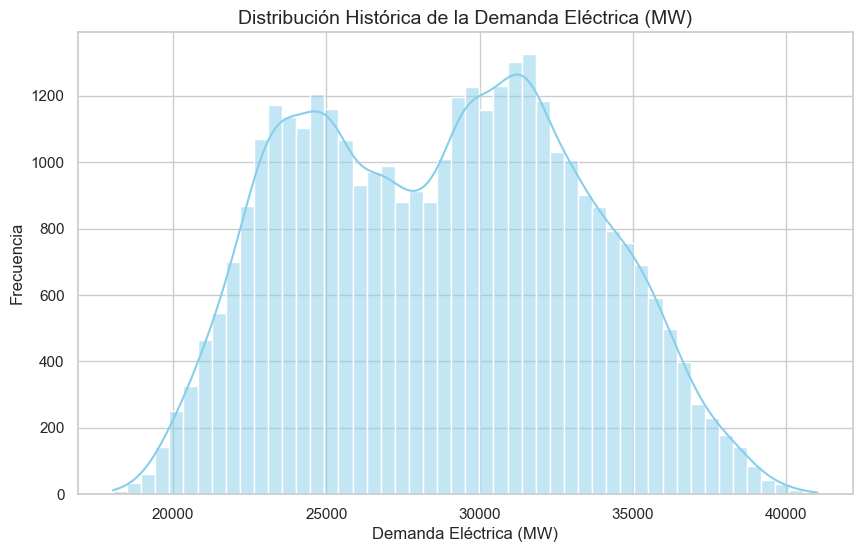

In [7]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))
sns.histplot(df['total_load_actual'], bins=50, kde=True, color='skyblue')
plt.title('Distribución Histórica de la Demanda Eléctrica (MW)', fontsize=14)
plt.xlabel('Demanda Eléctrica (MW)')
plt.ylabel('Frecuencia')
plt.show()

#### 4.3.2 Relación entre Clima y Demanda

Este es un mapa de puntos donde cada punto representa una hora del histórico. El eje X mide la temperatura en Madrid y el eje Y mide la demanda total de España en esa misma hora.

Esta gráfica ilustra un fenómeno clave en la ingeniería energética: la dependencia térmica no lineal. Como se puede apreciar, la nube de puntos forma una especie de "U". La demanda sube drásticamente en los extremos izquierdo (bajas temperaturas invernales que activan calefacciones) y derecho (altas temperaturas estivales que activan aires acondicionados), mientras que en el centro (temperaturas suaves de primavera/otoño) el consumo se relaja. Esta no linealidad nos indica que usar solo modelos lineales simples podría no ser suficiente para captar la complejidad climática.

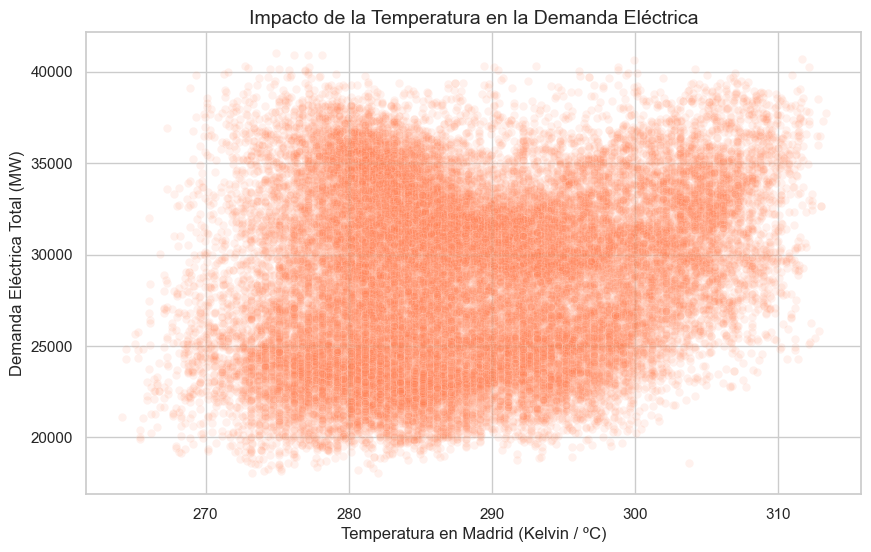

In [8]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='temp_madrid', y='total_load_actual', alpha=0.1, color='coral')
plt.title('Impacto de la Temperatura en la Demanda Eléctrica', fontsize=14)
plt.xlabel('Temperatura en Madrid (Kelvin / ºC)')
plt.ylabel('Demanda Eléctrica Total (MW)')
plt.show()

**Conclusiones de la Relación Clima-Demanda:**
* **El efecto estacional en forma de "U":** Se confirma visualmente la no linealidad del consumo. En el centro de la gráfica (temperaturas suaves, en torno a los 15-20ºC), la demanda es mínima. Sin embargo, se disparan dos brazos ascendentes: uno a la izquierda (bajas temperaturas por uso masivo de calefacción) y uno a la derecha (altas temperaturas por sistemas de refrigeración).
Esta relación no lineal nos advierte de que incluir la "temperatura" en crudo en una regresión lineal dará malos resultados (ya que el modelo intentará trazar una sola línea recta a través de una "U"). Esto justifica la necesidad de crear características polinómicas o utilizar algoritmos basados en árboles de decisión que captan relaciones no lineales de forma nativa.

#### 4.3.3. Análisis de Tendencia Histórica

En esta gráfica se representa la evolución cronológica ininterrumpida de la demanda eléctrica total (MW) durante los 4 años que abarca nuestro dataset (2015 - 2018). Para suavizar el ruido extremo de los datos hora a hora y poder ver la "imagen general" de forma clara, se ha aplicado una media móvil semanal (de 168 horas).

Esto nos permite comprobar de un vistazo si el consumo general del país está subiendo año tras año (tendencia alcista), cayendo (tendencia bajista) o si se mantiene estable repitiendo sus ciclos (estacionariedad).

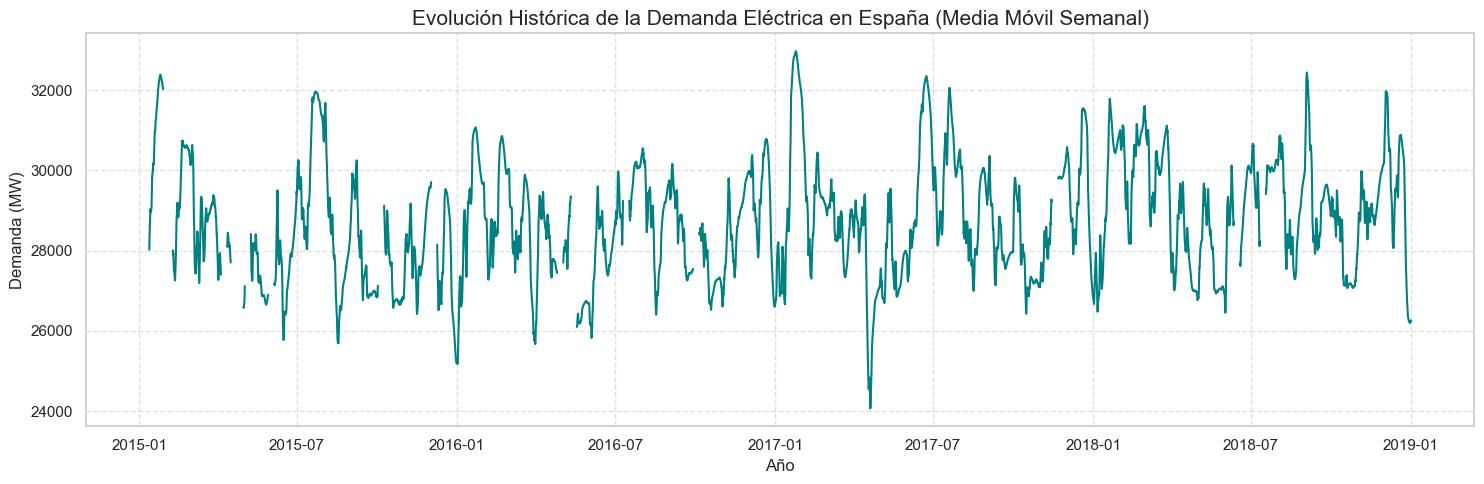

In [9]:
plt.figure(figsize=(15, 5))

df_suavizado = df.set_index('time_local')['total_load_actual'].rolling(window=168).mean()

plt.plot(df_suavizado.index, df_suavizado.values, color='teal', linewidth=1.5)
plt.title('Evolución Histórica de la Demanda Eléctrica en España (Media Móvil Semanal)', fontsize=15)
plt.xlabel('Año')
plt.ylabel('Demanda (MW)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

**Conclusiones del Análisis de Tendencia Histórica:**
* **Estabilidad:** A nivel interanual (de 2015 a 2018), la serie temporal es estable. No se observa una tendencia a la subida o a la bajada. El rango de consumo se mantiene constante a lo largo de los años.

### 4.4 Patrones Temporales y Climáticos

#### 4.4.1 Perfil Horario Promedio de la Demanda

Aquí se muestra el consumo eléctrico medio para cada una de las 24 horas del día. La línea representa la media histórica, y el área sombreada representa la desviación estándar.

Es la representación visual del "ritmo de vida" de la sociedad española. Nos permite identificar los valles de madrugada y los picos de máxima exigencia para la red eléctrica.

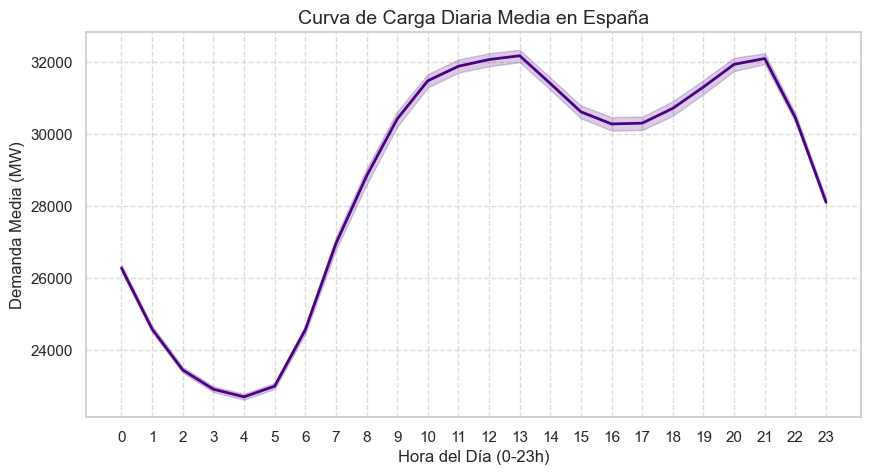

In [10]:
plt.figure(figsize=(10, 5))

sns.lineplot(data=df, x='hour', y='total_load_actual', color='indigo', linewidth=2)

plt.title('Curva de Carga Diaria Media en España', fontsize=14)
plt.xlabel('Hora del Día (0-23h)')
plt.ylabel('Demanda Media (MW)')
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

**Conclusiones del Perfil Horario:**
* **Ciclo vital humano:** La demanda sigue perfectamente el ciclo laboral y vital. Se observa un valle profundo a las 04:00h de la madrugada (mínimo consumo). A partir de las 06:00h comienza una subida pronunciada por el inicio de la actividad industrial y comercial.
* **El pico de la tarde/noche:** Se observa un ligero descenso a mediodía (coincidiendo con las horas de mayor insolación y menor actividad laboral), pero el verdadero pico de tensión de la red ocurre alrededor de las **20:00h - 21:00h**. La gente vuelve a casa, enciende electrodomésticos y luces, coincidiendo con la caída de la generación solar. La variable `hora` será el predictor más importante del modelo.

#### 4.4.2 Estacionalidad Mensual de la Demanda

Aquí comparamos la demanda media según el mes del año, esto nos permite cuantificar el impacto térmico global que vimos en el scatterplot, pero ordenado temporalmente.

C:\Users\marti\AppData\Local\Temp\ipykernel_8044\1567619888.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='month', y='total_load_actual', palette='Spectral', errorbar=None)


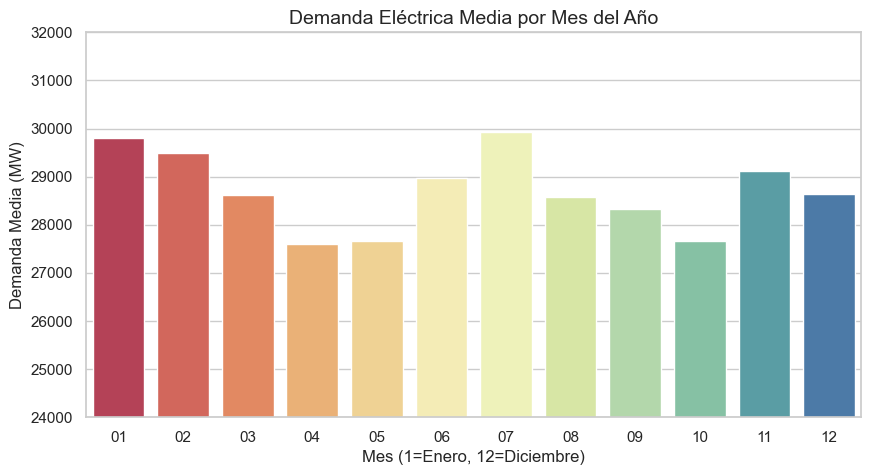

In [11]:
plt.figure(figsize=(10, 5))

# Agrupamos por mes y calculamos la media
sns.barplot(data=df, x='month', y='total_load_actual', palette='Spectral', errorbar=None)

plt.title('Demanda Eléctrica Media por Mes del Año', fontsize=14)
plt.xlabel('Mes (1=Enero, 12=Diciembre)')
plt.ylabel('Demanda Media (MW)')
# Establecemos el eje Y empezando en 20000 para magnificar las diferencias visuales
plt.ylim(24000, 32000) 
plt.show()

**Conclusiones de la Estacionalidad Mensual:**
* **Los picos térmicos:** Enero y julio destacan claramente como los meses de mayor consumo medio, esto es debido al consumo de la calefacción o del AC.
* **El valle de primavera/otoño:** Abril y mayo, junto con noviembre, presentan los consumos medios más bajos debido a las temperaturas suaves que no requieren climatización activa en los hogares.

#### 4.4.3 Interacción Horaria y Estacional

Esta gráfica combina las dos ideas anteriores. Muestra la curva horaria a lo largo del día, pero separada por las estaciones con más consumo y es crucial para descubrir si el comportamiento de la gente (a qué hora se gasta más) cambia dependiendo de si es verano o invierno.

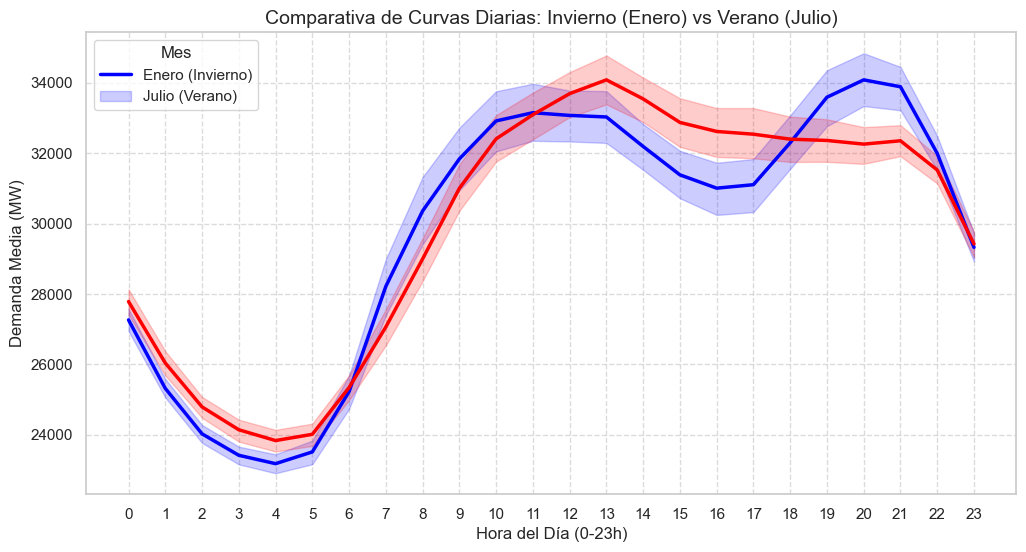

In [12]:

plt.figure(figsize=(12, 6))

# Convertimos month a número para la gráfica
df['month'] = df['month'].astype(int)

# Filtramos solo enero  y julio
df_estaciones = df[df['month'].isin([1, 7])]

sns.lineplot(data=df_estaciones, x='hour', y='total_load_actual', hue='month', 
             palette=['blue', 'red'], linewidth=2.5)

plt.title('Comparativa de Curvas Diarias: Invierno (Enero) vs Verano (Julio)', fontsize=14)
plt.xlabel('Hora del Día (0-23h)')
plt.ylabel('Demanda Media (MW)')
plt.xticks(range(0, 24))

# leyenda
plt.legend(['Enero (Invierno)', 'Julio (Verano)'], title='Mes')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

**Conclusiones de la Interacción:**
* **Desplazamiento del pico:** Esta es la gráfica más reveladora. Mientras que en invierno (línea azul) el pico absoluto de consumo nacional ocurre por la tarde/noche (20:00h, cuando anochece pronto y hace frío), en verano (línea roja) el comportamiento es distinto, llegando al punto más alto a las 13:00 y teniendo una suave pendiente descendiente hasta las 21:00.

### 4.5 Análisis de correlaciones

El último paso de nuestro análisis exploratorio es evaluar matemáticamente cómo se relacionan todas nuestras variables entre sí con una matríz de correlación. 

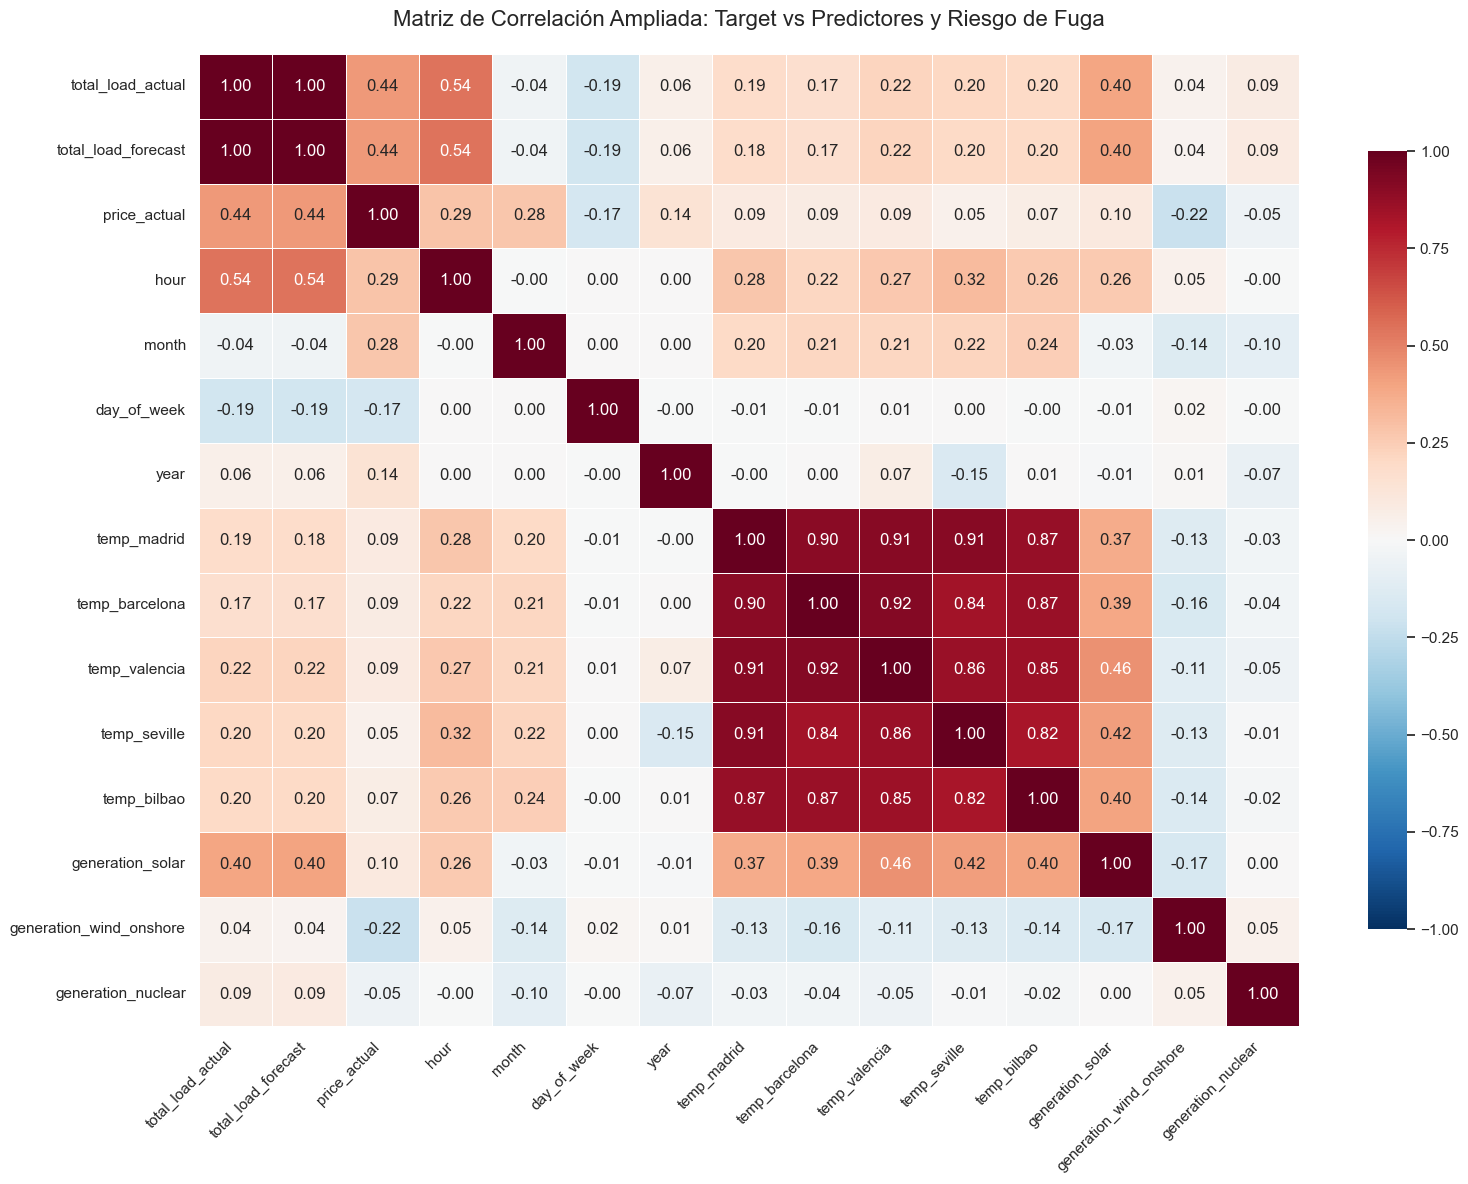

In [13]:
plt.figure(figsize=(16, 12)) 

cols_ampliadas = [
    'total_load_actual', 
    'total_load_forecast',       
    'price_actual',          
    'hour', 'month', 'day_of_week', 'year',
    'temp_madrid', 'temp_barcelona', 'temp_valencia', 'temp_seville', 'temp_bilbao',
    'generation_solar', 'generation_wind_onshore', 'generation_nuclear'
]

matriz_corr_ampliada = df[cols_ampliadas].corr()

sns.heatmap(matriz_corr_ampliada, annot=True, cmap='RdBu_r', vmin=-1, vmax=1, fmt=".2f", 
            linewidths=.5, cbar_kws={"shrink": .8})

plt.title('Matriz de Correlación Ampliada: Target vs Predictores y Riesgo de Fuga', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Conclusiones de la Matriz Ampliada y Decisiones Finales:**

* **1. Fuga de Información Crítica (`total_load_forecast`):** Vemos que la correlación entre la demanda real y la previsión  es casi perfecta. Sin embargo, **debemos eliminar esta variable**. Nuestro objetivo es construir un modelo que *haga* esa previsión. Si le damos al algoritmo las respuestas hechas por el operador de la red, el modelo no estará aprendiendo a predecir, solo estará copiando.
* **2. Variables Consecuencia (`price_actual` y `generation`):** El precio de la luz tiene una correlación moderada/alta con la demanda. Sin embargo, en el mercado eléctrico, **el precio es una consecuencia de la demanda**, no su causa (ley de oferta y demanda). Además, si queremos predecir la demanda de "mañana", hoy no conocemos con exactitud ni el precio real de mañana ni los MW exactos que generará la energía nuclear o solar mañana. Incluir estas variables engañaría al modelo haciéndole parecer artificialmente preciso. **Quedan descartadas.**
* **3. La Trampa de las temperaturas:** La correlación lineal directa con las temperaturas parece cercana a 0. Pero como ya hemos visto en otros diagramas como el de dispersión o el del consumo horario si existe una relación entre ambas.
* **4. Temperaturas redundantes:** Al observar las temperaturas entre sí, detectamos colinealidad extrema (ej. Barcelona y Valencia tienen una correlación >0.90). Para evitar el sobreajuste (overfitting) y simplificar el modelo, **podriamos ver de prescindir de Valencia y Bilbao**, manteniendo a Madrid (centro), Sevilla (sur caluroso) y Barcelona (costa mediterránea) como pilares climáticos.

**Conclusión Final de Selección:** El modelo predictivo se alimentará exclusivamente de las variables que sí conocemos antes de que ocurra el evento: **El calendario (`hour`, `day_of_week`, `month`) y las previsiones meteorológicas (`temp_madrid`, `temp_barcelona`, `temp_seville`).**

## 5. Preparación del Conjunto de Datos (Feature Engineering)

En esta fase transformaremos el dataset original en la matriz matemática final que alimentará nuestro modelo predictivo, cumpliendo con los requisitos de limpieza, adecuación e ingeniería de características.




### 5.1. Selección Final y Prevención de Data Leakage (Fuga de Información)

**Justificación de las variables eliminadas:**
Basándonos en los resultados de nuestro EDA (Matriz de Correlación Ampliada), aplicamos un filtrado estricto para garantizar que nuestro modelo sea matemáticamente válido y aplicable en un entorno operativo real. Se descartan las siguientes familias de variables:

* **1. Variables de Precios y Previsiones (`price_actual`, `total_load_forecast`):** Se eliminan por riesgo crítico de **Fuga de Información**. El objetivo de este modelo es predecir la demanda futura. En la vida real, en el momento de ejecutar la predicción, no disponemos del precio real de la luz de mañana. Entrenar al algoritmo dándole las respuestas por adelantado invalidaría el modelo.
* **2. Variables de Generación Eléctrica (`generation_solar`, `generation_wind`, etc.):** Se excluyen por dos motivos. Primero, de nuevo, por *Fuga de Datos* (no sabemos a priori cuántos MW generará el viento mañana a las 15:00h). Segundo, por un principio de **Causalidad**: la generación eléctrica es una *consecuencia* de la demanda. El modelo debe aprender los verdaderos móviles del consumo como el reloj social y el clima.
* **3. Temperaturas Redundantes (`temp_valencia`, `temp_bilbao`):** Se eliminan por **Multicolinealidad**. Como vimos en el Heatmap, están altamente correlacionadas con otras ciudades. Para evitar la "maldición de la dimensionalidad" y el sobreajuste (overfitting), conservamos únicamente Madrid (clima central/continental), Barcelona (costa mediterránea) y Sevilla (extremo sur caluroso) como sensores climáticos de la Península.

In [14]:
# Definimos la lista estricta de columnas
columnas_finales = [
    'time_local',        
    'total_load_actual', 
    'hour', 'month', 'day_of_week',
    'temp_madrid', 'temp_barcelona', 'temp_seville'
]

# Filtramos el dataframe original
df_model = df[columnas_finales].copy()

#Ordenamos cronológicamente para evitar aprender del futuro
df_model = df_model.sort_values('time_local').reset_index(drop=True)

print(f"Dimensiones tras la selección: {df_model.shape}")

Dimensiones tras la selección: (35064, 8)


### 5.2: Inspección de Calidad Final

In [15]:
print("--- TIPOS DE DATOS ---")
print(df_model.dtypes)
print("\n--- RECUENTO DE VALORES NULOS ---")
print(df_model.isnull().sum())

--- TIPOS DE DATOS ---
time_local           datetime64[ns, Europe/Madrid]
total_load_actual                          float64
hour                                         int32
month                                        int32
day_of_week                                  int32
temp_madrid                                float64
temp_barcelona                             float64
temp_seville                               float64
dtype: object

--- RECUENTO DE VALORES NULOS ---
time_local            0
total_load_actual    36
hour                  0
month                 0
day_of_week           0
temp_madrid           0
temp_barcelona        0
temp_seville          0
dtype: int64


In [16]:
display(df_model.head(3))

,time_local,total_load_actual,hour,month,day_of_week,temp_madrid,temp_barcelona,temp_seville
0,2015-01-01 00:00:00+01:00,25385.0,0,1,3,267.325,281.625,273.375
1,2015-01-01 01:00:00+01:00,24382.0,1,1,3,267.325,281.625,273.375
2,2015-01-01 02:00:00+01:00,22734.0,2,1,3,266.186,281.286,274.086


#### 5.2.1. Manejo de Valores Faltantes

El análisis de calidad ha revelado la existencia de **36 valores nulos** en nuestra variable objetivo `total_load_actual`. Dado que representan apenas un 0.1% del volumen total (35.064 horas) y se trata de una serie temporal continua, la técnica más robusta y matemáticamente correcta es la **Interpolación Lineal**. 
Este método rellena el hueco trazando una línea recta entre el valor de la hora anterior y el de la hora siguiente, preservando la continuidad de la curva de demanda sin alterar la media global ni introducir sesgos artificiales.

In [17]:
# Aplicamos interpolación linea
df_model['total_load_actual'] = df_model['total_load_actual'].interpolate(method='linear')

# Verificación
print("--- RECUENTO DE NULOS TRAS LA IMPUTACIÓN ---")
print(df_model.isnull().sum())

--- RECUENTO DE NULOS TRAS LA IMPUTACIÓN ---
time_local           0
total_load_actual    0
hour                 0
month                0
day_of_week          0
temp_madrid          0
temp_barcelona       0
temp_seville         0
dtype: int64


### 5.3. Ingeniería de Características: Variables Temporales

Para dotar al modelo de contexto histórico, crearemos variables basadas en el pasado inmediato.

* **Lags:** Consumo de hace exactamente 24 horas y hace 168 horas (1 semana).
* **Rolling:** Consumo medio de las últimas 24 horas.

In [18]:
#Lags
df_model['lag_24h'] = df_model['total_load_actual'].shift(24)
df_model['lag_168h'] = df_model['total_load_actual'].shift(168)

#Rolling
df_model['rolling_mean_24h'] = df_model['total_load_actual'].shift(1).rolling(window=24).mean()

#Borramos los valores nulos que se generan por falta de historial
df_model = df_model.dropna().reset_index(drop=True)

print(f"Dimensiones tras añadir memoria temporal y limpiar NaNs iniciales: {df_model.shape}")

Dimensiones tras añadir memoria temporal y limpiar NaNs iniciales: (34896, 11)


### 5.4. División del Dataset (Train / Test Split Temporal)

Dividiremos los datos en Entrenamiento (80%) y Prueba (20%). 
Al tratarse de una serie temporal, **no se barajan los datos** (`shuffle=False`). Se respeta el orden cronológico absoluto para entrenar al modelo con el pasado y evaluarlo prediciendo el futuro.

In [19]:
# Calculamos el índice exacto de corte (80%)
indice_corte = int(len(df_model) * 0.8)

# Partición cronológica
train_df = df_model.iloc[:indice_corte].copy()
test_df = df_model.iloc[indice_corte:].copy()

# Separamos Predictores (X) del Objetivo (y)
features = ['hour', 'month', 'day_of_week', 'temp_madrid', 'temp_barcelona', 'temp_seville', 
            'lag_24h', 'lag_168h', 'rolling_mean_24h']
target = 'total_load_actual'

X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

print(f"Train: {X_train.shape[0]} horas. Desde {train_df['time_local'].min()} hasta {train_df['time_local'].max()}")
print(f"Test:  {X_test.shape[0]} horas. Desde {test_df['time_local'].min()} hasta {test_df['time_local'].max()}")

Train: 27916 horas. Desde 2015-01-08 00:00:00+01:00 hasta 2018-03-16 03:00:00+01:00
Test:  6980 horas. Desde 2018-03-16 04:00:00+01:00 hasta 2018-12-31 23:00:00+01:00


### 5.5. Escalado de Características (Standardization)

Nuestras variables manejan escalas muy distintas (Kelvin, MW, horas). Para ayudar a la convergencia matemática de los modelos, estandarizamos las variables (media 0, varianza 1).

El motivo fundamental por ela estandarización se aplica después de haber dividido el dataset en conjuntos de Entrenamiento (Train) y Prueba (Test) es para prevenir la Fuga de Información (Data Leakage).

Algoritmos de escalado como StandardScaler transforman los datos restando la media y dividiendo por la desviación estándar de cada variable. Si aplicáramos esta transformación al dataset completo antes de realizar la partición temporal, estaríamos utilizando los datos del conjunto de Prueba (el "futuro") para calcular esa media y desviación estándar globales.

In [20]:
# Inicializamos
scaler = StandardScaler()

# Fit solo en Train, y transform en ambos
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Reconvertimos a DataFrame para mantener los nombres de las columnas
X_train_scaled = pd.DataFrame(X_train_scaled, columns=features, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=features, index=X_test.index)

display(X_train_scaled.head(3))

,hour,month,day_of_week,temp_madrid,temp_barcelona,temp_seville,lag_24h,lag_168h,rolling_mean_24h
0,-1.660985,-1.490825,-0.000072,-2.114699,-0.733176,-1.988330,0.402000,-0.711810,1.320143
1,-1.516534,-1.490825,-0.000072,-2.151060,-0.763140,-2.019413,-0.041278,-0.930393,1.260347
2,-1.372082,-1.490825,-0.000072,-2.187421,-0.793105,-2.050495,-0.359027,-1.289540,1.206834


## 6. Creación, Entrenamiento y Validación de Modelos

El objetivo es entrenar algoritmos para que aprendan la relación entre nuestros predictores y la demanda real. Cumpliendo con los requisitos del proyecto, compararemos dos modelos distintos, modificaremos sus parámetros mediante validación cruzada y evaluaremos su bondad de ajuste (MAE, RMSE, R²).

### 6.1. Definición de la Función de Evaluación

In [21]:
def evaluar_modelo(y_true, y_pred, nombre_modelo):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    
    print(f"=========================================")
    print(f"RESULTADOS: {nombre_modelo.upper()}")
    print(f"=========================================")
    print(f" -> MAE  : {mae:.2f} MW")
    print(f" -> RMSE : {rmse:.2f} MW")
    print(f" -> R²   : {r2:.4f} ({(r2*100):.2f}%)")
    print(f"=========================================\n")
    return mae, rmse, r2

### 6.2 Modelos

**Justificación de la selección:**
Para esta primera fase de entrenamiento, hemos seleccionado tres algoritmos de distinta naturaleza.
1. **Regresión Ridge (Línea Base Lineal):** Es una evolución de la Regresión Lineal clásica que incluye regularización para evitar el sobreajuste. La utilizamos como nuestro "modelo de control". Dado que la relación entre clima y demanda no es lineal (tiene forma de "U"), esperamos que este modelo alcance un techo, demostrando la necesidad de algoritmos más complejos.
2. **Random Forest Regressor:** Crea cientos de árboles de decisión independientes. Es teóricamente ideal para captar relaciones no lineales sin necesidad de complejas transformaciones trigonométricas.
3. **XGBoost (Extreme Gradient Boosting):**"Constituye uno de los modelos más avanzados y eficaces en la actualidad para el análisis predictivo con datos estructurado. Aprende secuencialmente de sus propios errores y está altamente optimizado.

#### 6.2.1. Entrenamiento Modelo 1: Regresión Ridge

In [22]:
print("Optimizando Regresión Ridge...")

# Búsqueda de hiperparámetros mediante validación cruzada
parametros_ridge = {'alpha': [0.1, 1.0, 10.0, 50.0, 100.0]}
grid_ridge = GridSearchCV(Ridge(), parametros_ridge, cv=3, scoring='r2')
grid_ridge.fit(X_train_scaled, y_train)

# Selección del modelo óptimo
mejor_ridge = grid_ridge.best_estimator_
print(f"Mejor parámetro seleccionado: {grid_ridge.best_params_}")

# Predicción y evaluación en el conjunto de prueba
y_pred_ridge = mejor_ridge.predict(X_test_scaled)
evaluar_modelo(y_test, y_pred_ridge, "Regresión Ridge")

Optimizando Regresión Ridge...
Mejor parámetro seleccionado: {'alpha': 100.0}
RESULTADOS: REGRESIÓN RIDGE
 -> MAE  : 2018.61 MW
 -> RMSE : 2693.92 MW
 -> R²   : 0.6445 (64.45%)



(2018.607539188593, 2693.918846014506, 0.6445406997490176)

#### 6.2.2 Modelo 2: Random Forest Regressor

In [23]:
print("Optimizando Random Forest...")

# Búsqueda de hiperparámetros mediante validación cruzada
parametros_rf = {
    'n_estimators': [50, 100], 
    'max_depth': [10, 15]
}
random_rf = RandomizedSearchCV(RandomForestRegressor(random_state=42, n_jobs=-1), 
                               param_distributions=parametros_rf, n_iter=4, cv=3, random_state=42)
random_rf.fit(X_train_scaled, y_train)

# Selección del modelo óptimo
mejor_rf = random_rf.best_estimator_
print(f"Mejores parámetros seleccionados: {random_rf.best_params_}")

# Predicción y evaluación en el conjunto de prueba
y_pred_rf = mejor_rf.predict(X_test_scaled)
evaluar_modelo(y_test, y_pred_rf, "Random Forest (Baseline)")

Optimizando Random Forest...
Mejores parámetros seleccionados: {'n_estimators': 100, 'max_depth': 15}
RESULTADOS: RANDOM FOREST (BASELINE)
 -> MAE  : 1044.20 MW
 -> RMSE : 1528.17 MW
 -> R²   : 0.8856 (88.56%)



(1044.1998520038899, 1528.1697914045624, 0.8856163145771552)

#### 6.2.3 Modelo 4: XGBoost Regressorº

In [24]:
print("Optimizando XGBoost...")

# Búsqueda de hiperparámetros mediante validación cruzada
parametros_xgb = {
    'n_estimators': [100, 150], 
    'learning_rate': [0.05, 0.1],
    'max_depth': [5, 7]
}
random_xgb = RandomizedSearchCV(xgb.XGBRegressor(random_state=42, n_jobs=-1), 
                               param_distributions=parametros_xgb, n_iter=4, cv=3, random_state=42)
random_xgb.fit(X_train_scaled, y_train)

# Selección del modelo óptimo
mejor_xgb = random_xgb.best_estimator_
print(f"Mejores parámetros seleccionados: {random_xgb.best_params_}")

# Predicción y evaluación en el conjunto de prueba
y_pred_xgb = mejor_xgb.predict(X_test_scaled)
evaluar_modelo(y_test, y_pred_xgb, "XGBoost (Baseline)")

Optimizando XGBoost...
Mejores parámetros seleccionados: {'n_estimators': 150, 'max_depth': 7, 'learning_rate': 0.1}
RESULTADOS: XGBOOST (BASELINE)
 -> MAE  : 1022.70 MW
 -> RMSE : 1495.42 MW
 -> R²   : 0.8905 (89.05%)



(1022.7016285368911, 1495.415746626936, 0.8904670553073539)

### 6.3. Evaluación Comparativa y Selección de Modelos

Vemos que modelos son los más óptimos antes de continuar la optmización para comprobar si alguno se queda demasiado atrás.

In [25]:
# Agrupación de los modelos base entrenados
modelos_base = {
    "Regresión Ridge": mejor_ridge,
    "Random Forest": mejor_rf,
    "XGBoost": mejor_xgb
}

lista_resultados = []

# Evaluación y extracción de métricas
for nombre, modelo in modelos_base.items():
    y_pred = modelo.predict(X_test_scaled)
    
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    lista_resultados.append({
        "Modelo": nombre,
        "R² (%)": round(r2 * 100, 2),
        "MAE (MW)": round(mae, 2),
        "RMSE (MW)": round(rmse, 2)
    })

# Consolidación y ordenación de los resultados
df_comparativa_base = pd.DataFrame(lista_resultados)
df_comparativa_base = df_comparativa_base.sort_values(by="R² (%)", ascending=False).reset_index(drop=True)
display(df_comparativa_base)

,Modelo,R² (%),MAE (MW),RMSE (MW)
0,XGBoost,89.05,1022.70,1495.42
1,Random Forest,88.56,1044.20,1528.17
2,Regresión Ridge,64.45,2018.61,2693.92


**Conclusiones de la Evaluación Base:**

Al observar la tabla comparativa, la arquitectura matemática de los modelos explica claramente sus resultados:

* **El Límite del Modelo Lineal:** La Regresión Ridge se posiciona en último lugar. Aunque es un modelo rápido y robusto, su naturaleza lineal le impide comprender matemáticamente que tanto a los 5ºC como a los 35ºC el consumo eléctrico sube (forma de "U"). Para la Regresión, la línea solo puede ir en una dirección, lo que limita su capacidad predictiva y aumenta su margen de error (MAE).
* **La Superioridad de los Árboles:** Por el contrario, XGBoost y Random Forest superan ampliamente el 88% de varianza $R^2$. Al estar basados en árboles de decisión, pueden hacer divisiones lógicas, captando a la perfección la estacionalidad climática.

Habiendo validado que una aproximación puramente lineal no es suficiente para resolver la complejidad de la demanda eléctrica, **descartamos la Regresión Ridge**. Para la siguiente fase de experimentación avanzada, nos quedaremos exclusivamente con nuestros dos modelos campeones: **XGBoost y Random Forest**.

### 6.4. Optimización y creación de nuevas variables

Como ya hemos visto que XGBoost es el modelo que mejor funciona (con un $R^2$ inicial del **89.05%**), ahora vamos a intentar mejorar esa nota creando variables nuevas.

Para evitar confundir al algoritmo metiéndole demasiados datos de golpe, vamos a ir probando estas nuevas variables una a una:
1. Entrenamos el modelo añadiendo la nueva variable.
2. Si el porcentaje de acierto ($R^2$) mejora y el error (MAE) baja, **nos quedamos con la variable**.
3. Si el resultado empeora o se queda igual, **la descartamos**.

Vamos a añadir variables para **días festivos, fines de semana, horario laboral yº temperaturas extremas.**

In [ ]:


# Inicialización del conjunto de variables predictoras base
variables_ganadoras = features.copy()
record_r2 = 0.8905  # R² de referencia del modelo XGBoost

print(f"R² de referencia a superar: {record_r2 * 100:.2f}%")

# Generación de variables experimentales en los conjuntos de entrenamiento y prueba

# 1. Festivos nacionales
festivos = holidays.Spain(years=[2015, 2016, 2017, 2018])
train_df['is_holiday'] = train_df['time_local'].dt.date.apply(lambda x: 1 if x in festivos else 0)
test_df['is_holiday'] = test_df['time_local'].dt.date.apply(lambda x: 1 if x in festivos else 0)

# 2. Fines de semana
train_df['is_weekend'] = train_df['time_local'].dt.dayofweek.apply(lambda x: 1 if x >= 5 else 0)
test_df['is_weekend'] = test_df['time_local'].dt.dayofweek.apply(lambda x: 1 if x >= 5 else 0)

# 3. Horario laboral (08:00 - 18:00)
train_df['is_business_hour'] = train_df['time_local'].dt.hour.apply(lambda x: 1 if 8 <= x <= 18 else 0)
test_df['is_business_hour'] = test_df['time_local'].dt.hour.apply(lambda x: 1 if 8 <= x <= 18 else 0)

# 4. Temperaturas extremas (>32ºC o <5ºC)
train_df['is_extreme_temp'] = train_df['temp_madrid'].apply(lambda x: 1 if x > 305.15 or x < 278.15 else 0)
test_df['is_extreme_temp'] = test_df['temp_madrid'].apply(lambda x: 1 if x > 305.15 or x < 278.15 else 0)

print("Variables experimentales generadas con éxito.")

R² de referencia a superar: 89.05%
Variables experimentales generadas con éxito.


#### 6.4.1 Festivos

In [27]:
print("--- EXPERIMENTO 1: AÑADIENDO FESTIVOS ---")
features_prueba = variables_ganadoras + ['is_holiday']

# Escalado de variables para el modelo
scaler_prueba = StandardScaler()
X_train_pr = pd.DataFrame(scaler_prueba.fit_transform(train_df[features_prueba]), columns=features_prueba)
X_test_pr = pd.DataFrame(scaler_prueba.transform(test_df[features_prueba]), columns=features_prueba)

# Entrenamiento y evaluación del modelo
random_xgb.fit(X_train_pr, y_train)
y_pred_pr = random_xgb.best_estimator_.predict(X_test_pr)
mae, rmse, r2 = evaluar_modelo(y_test, y_pred_pr, "XGBoost (+ Festivos)")

# Validación de rendimiento e integración de la variable
if r2 > record_r2:
    print("Mejora de rendimiento detectada. Variable 'is_holiday' incorporada al modelo final.")
    variables_ganadoras.append('is_holiday')
    record_r2 = r2
else:
    print("Rendimiento inferior o estancado. Variable 'is_holiday' descartada.")

--- EXPERIMENTO 1: AÑADIENDO FESTIVOS ---
RESULTADOS: XGBOOST (+ FESTIVOS)
 -> MAE  : 1014.24 MW
 -> RMSE : 1484.70 MW
 -> R²   : 0.8920 (89.20%)

Mejora de rendimiento detectada. Variable 'is_holiday' incorporada al modelo final.


#### 6.4.2 Fin de semana

In [28]:
print("--- EXPERIMENTO 2: AÑADIENDO FIN DE SEMANA ---")
features_prueba = variables_ganadoras + ['is_weekend']

# Escalado de variables para el modelo
scaler_prueba = StandardScaler()
X_train_pr = pd.DataFrame(scaler_prueba.fit_transform(train_df[features_prueba]), columns=features_prueba)
X_test_pr = pd.DataFrame(scaler_prueba.transform(test_df[features_prueba]), columns=features_prueba)

# Entrenamiento y evaluación del modelo
random_xgb.fit(X_train_pr, y_train)
y_pred_pr = random_xgb.best_estimator_.predict(X_test_pr)
mae, rmse, r2 = evaluar_modelo(y_test, y_pred_pr, "XGBoost (+ Fin de Semana)")

# Validación de rendimiento e integración de la variable
if r2 > record_r2:
    print("Mejora de rendimiento detectada. Variable 'is_weekend' incorporada al modelo final.")
    variables_ganadoras.append('is_weekend')
    record_r2 = r2
else:
    print("Rendimiento inferior o estancado. Variable 'is_weekend' descartada por redundancia.")

--- EXPERIMENTO 2: AÑADIENDO FIN DE SEMANA ---
RESULTADOS: XGBOOST (+ FIN DE SEMANA)
 -> MAE  : 1014.24 MW
 -> RMSE : 1484.70 MW
 -> R²   : 0.8920 (89.20%)

Rendimiento inferior o estancado. Variable 'is_weekend' descartada por redundancia.


#### 6.4.3 Horario laboral

In [29]:
print("--- EXPERIMENTO 3: AÑADIENDO HORARIO LABORAL ---")
features_prueba = variables_ganadoras + ['is_business_hour'] 

# Escalado de variables para el modelo
scaler_prueba = StandardScaler()
X_train_pr = pd.DataFrame(scaler_prueba.fit_transform(train_df[features_prueba]), columns=features_prueba)
X_test_pr = pd.DataFrame(scaler_prueba.transform(test_df[features_prueba]), columns=features_prueba)

# Entrenamiento y evaluación del modelo
random_xgb.fit(X_train_pr, y_train)
y_pred_pr = random_xgb.best_estimator_.predict(X_test_pr)
mae, rmse, r2 = evaluar_modelo(y_test, y_pred_pr, "XGBoost (+ Horario Laboral)")

# Validación de rendimiento e integración de la variable
if r2 > record_r2:
    print("Mejora de rendimiento detectada. Variable 'is_business_hour' incorporada al modelo final.")
    variables_ganadoras.append('is_business_hour')
    record_r2 = r2
else:
    print("Rendimiento inferior o estancado. Variable 'is_business_hour' descartada por redundancia.")

--- EXPERIMENTO 3: AÑADIENDO HORARIO LABORAL ---
RESULTADOS: XGBOOST (+ HORARIO LABORAL)
 -> MAE  : 1017.23 MW
 -> RMSE : 1488.06 MW
 -> R²   : 0.8915 (89.15%)

Rendimiento inferior o estancado. Variable 'is_business_hour' descartada por redundancia.


#### 6.4.4 Clima extremo

In [30]:
print("--- EXPERIMENTO 4: AÑADIENDO CLIMA EXTREMO ---")
features_prueba = variables_ganadoras + ['is_extreme_temp'] 

# Escalado de variables para el modelo
scaler_prueba = StandardScaler()
X_train_pr = pd.DataFrame(scaler_prueba.fit_transform(train_df[features_prueba]), columns=features_prueba)
X_test_pr = pd.DataFrame(scaler_prueba.transform(test_df[features_prueba]), columns=features_prueba)

# Entrenamiento y evaluación del modelo
random_xgb.fit(X_train_pr, y_train)
y_pred_pr = random_xgb.best_estimator_.predict(X_test_pr)
mae, rmse, r2 = evaluar_modelo(y_test, y_pred_pr, "XGBoost (+ Clima Extremo)")

# Validación de rendimiento e integración de la variable
if r2 > record_r2:
    print("Mejora de rendimiento detectada. Variable 'is_extreme_temp' incorporada al modelo final.")
    variables_ganadoras.append('is_extreme_temp')
    record_r2 = r2
else:
    print("Rendimiento inferior o estancado. Variable 'is_extreme_temp' descartada.")

--- EXPERIMENTO 4: AÑADIENDO CLIMA EXTREMO ---
RESULTADOS: XGBOOST (+ CLIMA EXTREMO)
 -> MAE  : 1013.80 MW
 -> RMSE : 1483.39 MW
 -> R²   : 0.8922 (89.22%)

Mejora de rendimiento detectada. Variable 'is_extreme_temp' incorporada al modelo final.


### 6.5 La importancia de los Lags

Para demostrar que usar datos del pasado es algo necesario para que el modelo funcione mejor vamor a proceder a las estas columnas para comprobar el rendimiento del modelo sin estas.
Hemos quitado todas las columnas que miran al pasado (lag_24h, lag_168h y rolling_mean_24h) y hemos obligado a nuestro mejor modelo (XGBoost) a adivinar el consumo usando únicamente los datos de ahora: el calendario, la hora y la temperatura.

In [31]:
print("--- EXPERIMENTO: XGBOOST SIN MEMORIA HISTÓRICA ---")

# Definición de variables excluyendo la memoria
features_sin_lags = [
    'hour', 
    'month', 
    'day_of_week', 
    'temp_madrid', 
    'temp_barcelona', 
    'temp_seville',
    'is_holiday',        
    'is_extreme_temp'    
]

print(f"Entrenando modelo sin lags con {len(features_sin_lags)} variables...")

# Escalado de variables para el conjunto de datos reducido
scaler_ablacion = StandardScaler()
X_train_ablacion = pd.DataFrame(scaler_ablacion.fit_transform(train_df[features_sin_lags]), columns=features_sin_lags)
X_test_ablacion = pd.DataFrame(scaler_ablacion.transform(test_df[features_sin_lags]), columns=features_sin_lags)

# Entrenamiento y evaluación del modelo sin registros históricos
modelo_nolag = xgb.XGBRegressor(n_estimators=150, max_depth=7, learning_rate=0.1, random_state=42)
modelo_nolag.fit(X_train_ablacion, y_train)

# PREDECIMOS CON EL MODELO NUEVO (CORREGIDO)
y_pred_ablacion = modelo_nolag.predict(X_test_ablacion)

mae_ab, rmse_ab, r2_ab = evaluar_modelo(y_test, y_pred_ablacion, "XGBoost (Sin Lags)")

print(f"IMPACTO DEL ESTUDIO:")
print(f"Rendimiento resultante: {(r2_ab*100):.2f}% (Rendimiento base: 89.22%).")

--- EXPERIMENTO: XGBOOST SIN MEMORIA HISTÓRICA ---
Entrenando modelo sin lags con 8 variables...
RESULTADOS: XGBOOST (SIN LAGS)
 -> MAE  : 1862.08 MW
 -> RMSE : 2666.05 MW
 -> R²   : 0.6519 (65.19%)

IMPACTO DEL ESTUDIO:
Rendimiento resultante: 65.19% (Rendimiento base: 89.22%).


**Conclusiones:**

Al quitarle la memoria histórica, el rendimiento del modelo se desploma (pasamos de un $R^2$ del 89.22% a un 67.35%). Esto comprueba que el consumo eléctrico no depende solo de lo que pasa en el instante actual, sino que se basa mucho en la rutina y la inercia de días anteriores. Con esto demostramos que usar lags es fundamental para darle al modelo la misma información lógica que tendría cualquier trabajador de Red Eléctrica para hacer su trabajo.


## 7. Representación Gráfica del Modelo

Una vez que hemos comprobado con números que **XGBoost** es nuestro mejor modelo, el siguiente paso es ver cómo se comporta visualmente. Las métricas como el $R^2$ o el MAE nos dan una nota general, pero las gráficas nos ayudan a entender realmente **dónde acierta el modelo, dónde falla y cómo toma sus decisiones**.

Para analizarlo a fondo, hemos dividido este apartado en cuatro subpuntos:
1. Importancia de las variables.
2. Gráfico de dispersión (Real vs Predicho).
3. Zoom temporal a una semana.
4. Distribución de los errores.

In [32]:
# Configuramos el estilo visual de todas las gráficas
sns.set_theme(style="whitegrid")

# Escalamos los datos usando la lista definitiva de variables ganadoras
scaler_final = StandardScaler()
X_train_final = pd.DataFrame(scaler_final.fit_transform(train_df[variables_ganadoras]), columns=variables_ganadoras)
X_test_final = pd.DataFrame(scaler_final.transform(test_df[variables_ganadoras]), columns=variables_ganadoras)

# Sacamos las predicciones finales del modelo XGBoost completo
y_pred_final = random_xgb.best_estimator_.predict(X_test_final)

### 7.1. Importancia de las Variables

En este primer gráfico vamos a ver en qué variables se apoya más el modelo para calcular la demanda eléctrica. XGBoost mide cuántas veces se usa cada característica para dividir los datos y tomar una decisión (F-score).

<Figure size 1000x600 with 0 Axes>

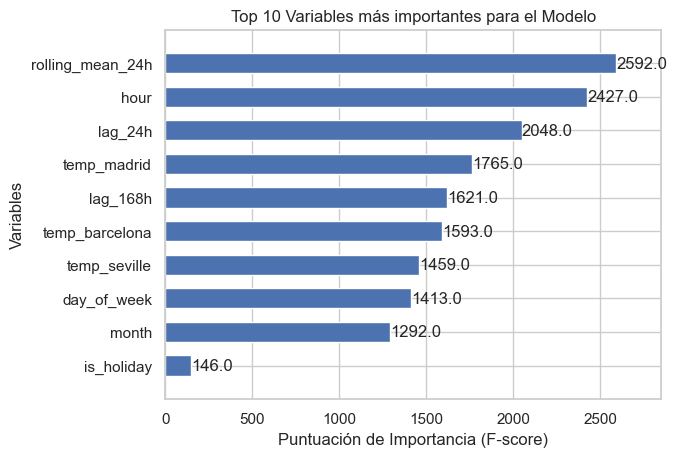

In [33]:
plt.figure(figsize=(10, 6))
plot_importance(random_xgb.best_estimator_, max_num_features=10, height=0.6, 
                title="Top 10 Variables más importantes para el Modelo",
                xlabel="Puntuación de Importancia (F-score)", ylabel="Variables")
plt.show()

**Conclusión del gráfico:**
Como se puede ver, las variables que miran al pasado (los *lags*) y la temperatura de Madrid son las auténticas "estrellas" del modelo. Esto tiene todo el sentido del mundo: para saber cuánta luz se va a gastar hoy a una hora concreta, lo más útil es saber cuánto se gastó ayer a esa misma hora y si hace frío o calor. Las variables de calendario ayudan a ajustar los detalles, pero la base del éxito son los *lags*.

Por otro lado, vemos que los días festivos `is_holiday` aparecen abajo del todo y apenas tienen peso en la gráfica. Esto es totalmente lógico, ya que hay muy pocos festivos a lo largo del año y suponen un porcentaje mínimo dentro de todo nuestro dataset. Al haber tan pocos días de este tipo, el modelo no necesita apoyarse tanto en ellos para hacer la predicción general.

### 7.2. Gráfico de Dispersión: Consumo Real vs Predicción

Aquí enfrentamos en un eje el consumo eléctrico real y en el otro lo que ha dicho nuestro modelo. La línea roja discontinua representa la "predicción perfecta" (donde el modelo acertaría el 100% de los megavatios). Cuanto más se pegue nuestra nube de puntos a esa línea, mejor.

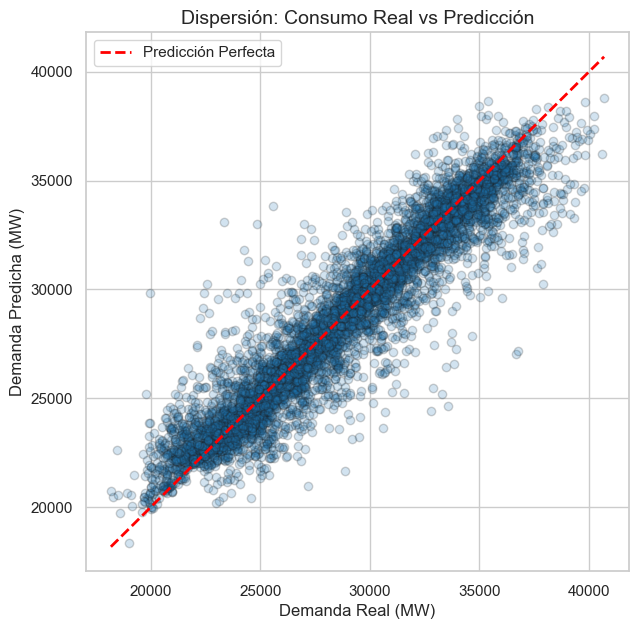

In [34]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred_final, alpha=0.2, color='#1f77b4', edgecolor='k')

# Línea de predicción perfecta
min_val = min(y_test.min(), y_pred_final.min())
max_val = max(y_test.max(), y_pred_final.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label="Predicción Perfecta")

plt.title("Dispersión: Consumo Real vs Predicción", fontsize=14)
plt.filename = "dispersion.png"
plt.xlabel("Demanda Real (MW)", fontsize=12)
plt.ylabel("Demanda Predicha (MW)", fontsize=12)
plt.legend()
plt.show()

**Conclusión del gráfico:**
La nube de puntos se ajusta muchísimo a la diagonal roja, lo que confirma de forma visual ese $R^2$ del ~89% que conseguimos en las métricas. Además, vemos que el modelo es muy estable: la línea se mantiene compacta tanto en consumos bajos como altos, lo que significa que el modelo no sobreestima la demanda cuando hay picos de consumo.

### 7.3. Zoom Temporal: Simulación de una Semana Completa

Para ver cómo funcionaría el modelo en el día a día de Red Eléctrica, en la primera semana del test. Pintamos la línea real en negro y la predicción de nuestro XGBoost en naranja.

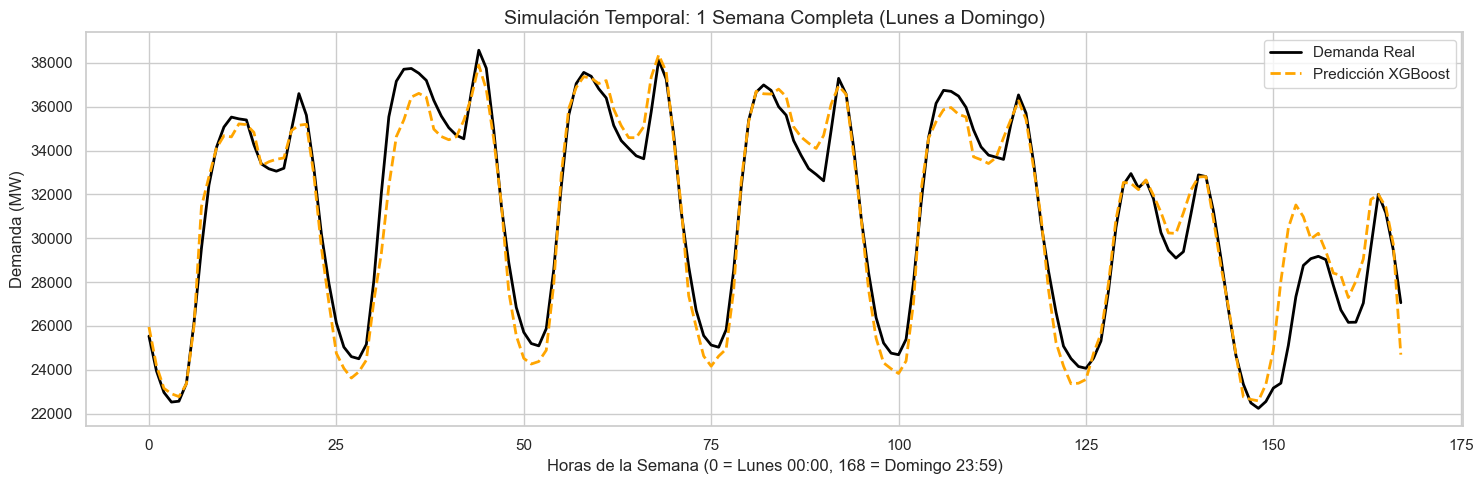

In [35]:
# Buscamos el primer Lunes en el conjunto de test (day_of_week == 0)
# Así nos aseguramos de que el gráfico siempre empieza en Lunes y acaba en Domingo.
primer_lunes_idx = test_df[test_df['day_of_week'] == 0].index[0]

# Extraemos las 168 horas (1 semana) a partir de ese lunes
semana_test_df = test_df.loc[primer_lunes_idx : primer_lunes_idx + 167]

semana_real = semana_test_df['total_load_actual'].values

# Buscamos qué posiciones (índices numéricos) corresponden en X_test_final
posicion_inicio = test_df.index.get_loc(primer_lunes_idx)
semana_pred = y_pred_final[posicion_inicio : posicion_inicio + 168]

plt.figure(figsize=(15, 5))
plt.plot(semana_real, label='Demanda Real', color='black', linewidth=2)
plt.plot(semana_pred, label='Predicción XGBoost', color='orange', linestyle='--', linewidth=2)

plt.title("Simulación Temporal: 1 Semana Completa (Lunes a Domingo)", fontsize=14)
plt.xlabel("Horas de la Semana (0 = Lunes 00:00, 168 = Domingo 23:59)", fontsize=12)
plt.ylabel("Demanda (MW)", fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

**Conclusión del gráfico:**
Esta gráfica es fundamental para entender cómo el modelo "respira" al ritmo de la sociedad. Al aislar una semana completa (de lunes a domingo), vemos que la línea naranja calca casi a la perfección los patrones de los días laborables: detecta la caída drástica de madrugada, el pico de la mañana y el gran repunte de la tarde/noche cuando llegamos a casa.

Sin embargo, hay un detalle muy interesante al final del gráfico: **el domingo es el día donde la predicción se aleja un poco más de la línea real**. Esto tiene todo el sentido lógico. De lunes a viernes nuestra rutina como país es muy estricta (horarios de trabajo, colegios, industria funcionando a pleno rendimiento), lo que hace que los datos sean muy matemáticos. El domingo, en cambio, es un día impredecible: el consumo depende de si la gente se queda en casa, de si salen a comer o de si hace buen tiempo. Al ser un día con menos "rutina" y sin industria pesada, es totalmente normal que al modelo le cueste un poco más afinar el número exacto, aunque sigue captando perfectamente la bajada general del consumo.

### 7.4. Distribución de los Errores

Por último, analizamos los "residuos", que es simplemente restar el consumo real menos lo que predijo el modelo. Queremos ver si cuando el modelo falla, lo hace por mucho o por poco, y si tiende a equivocarse siempre hacia el mismo lado.

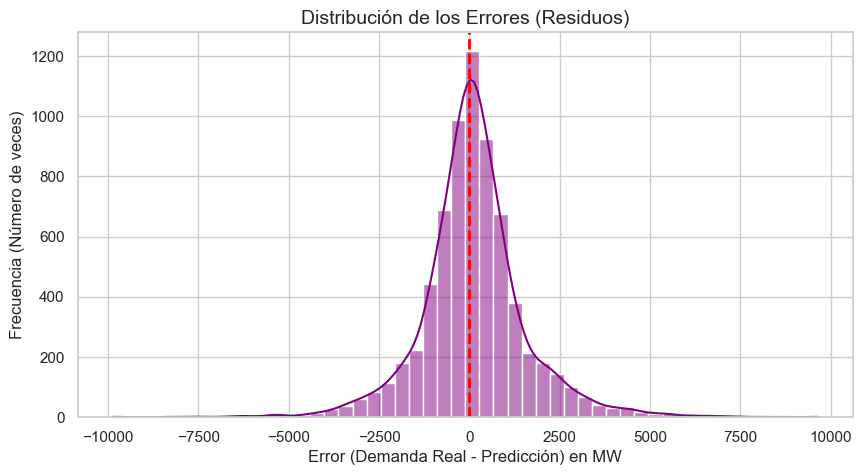

In [36]:
residuos = y_test.values.flatten() - y_pred_final

plt.figure(figsize=(10, 5))
sns.histplot(residuos, bins=50, kde=True, color='purple')
plt.axvline(x=0, color='red', linestyle='--', linewidth=2) 

plt.title("Distribución de los Errores (Residuos)", fontsize=14)
plt.xlabel("Error (Demanda Real - Predicción) en MW", fontsize=12)
plt.ylabel("Frecuencia (Número de veces)", fontsize=12)
plt.show()

**Conclusión del gráfico:**
Como vemos, los errores forman una campana perfecta centrada en el cero (el error ideal). Esto significa que la inmensa mayoría de las veces el error del modelo es minúsculo (está muy cerca de la línea roja del 0). Que tenga esta forma simétrica nos asegura que el modelo no tiene sesgos; es decir, no tiende a predecir sistemáticamente por encima ni por debajo de la realidad. Los fallos grandes son muy raros y aislados.

## 8. Guardado de modelos

In [37]:
# Creación del directorio de almacenamiento si no existe
carpeta_modelos = os.path.join(os.path.dirname(os.getcwd()), "modelos")
if not os.path.exists(carpeta_modelos):
    os.makedirs(carpeta_modelos)
    print(f"Directorio '{carpeta_modelos}' creado.")

# Exportación del modelo con memoria temporal (lags) y su escalador asociado
ruta_modelo = os.path.join(carpeta_modelos, "modelo_energia_es_lag.json")
random_xgb.best_estimator_.save_model(ruta_modelo)

ruta_escalador = os.path.join(carpeta_modelos, "escalador_energia_es_lag.pkl")
joblib.dump(scaler_final, ruta_escalador)

# Exportación del modelo secundario (sin lags) y su escalador asociado
ruta_modelo_nolag = os.path.join(carpeta_modelos, "modelo_energia_es.json")
modelo_nolag.save_model(ruta_modelo_nolag)

ruta_escalador_nolag = os.path.join(carpeta_modelos, "escalador_energia_es.pkl")
joblib.dump(scaler_ablacion, ruta_escalador_nolag)

print("Exportación de modelos y escaladores completada con éxito.")

Exportación de modelos y escaladores completada con éxito.


In [38]:
# Definición del directorio de salida y creación si es inexistente
dir_procesados = os.path.join(os.path.dirname(os.getcwd()), "datos_procesados")
if not os.path.exists(dir_procesados):
    os.makedirs(dir_procesados)

# Selección de variables para el conjunto de datos de inferencia
columnas_necesarias = [
    'total_load_actual', 'hour', 'month', 'day_of_week', 
    'temp_madrid', 'temp_barcelona', 'temp_seville', 
    'is_holiday', 'is_extreme_temp', 
    'lag_24h', 'lag_168h', 'rolling_mean_24h'
]

# Generación del subconjunto de datos
test_export = test_df[columnas_necesarias].copy()

# Integración de la marca temporal original
test_export['fecha_hora'] = df.loc[test_df.index, 'time']

# Verificación de la estructura temporal
print("Primeras 3 fechas recuperadas:\n", test_export['fecha_hora'].head(3))

# Exportación del conjunto de datos procesado
ruta_salida = os.path.join(dir_procesados, "datos_test_procesados.csv")
test_export.to_csv(ruta_salida, index=False)
print(f"Archivo procesado exportado en: {ruta_salida}")

Primeras 3 fechas recuperadas:
 27916   2018-03-09 03:00:00+00:00
27917   2018-03-09 04:00:00+00:00
27918   2018-03-09 05:00:00+00:00
Name: fecha_hora, dtype: datetime64[ns, UTC]
Archivo procesado exportado en: c:\Users\marti\Desktop\proyecto energia\datos_procesados\datos_test_procesados.csv
